In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("insurance.csv")

# Preview dataset
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Shape of the dataset
df.shape

# Column names
df.columns

# Data types and info
df.info()

# Summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Questions 
- Does smoking increase medical charges?
- Is there a relationship between age and charges?
- Does BMI affect insurance cost?
- Are there any outliers in the dataset?

In [4]:
# Missing values
df.isnull().sum()

# Duplicate values
df.duplicated().sum()

np.int64(1)

In [5]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

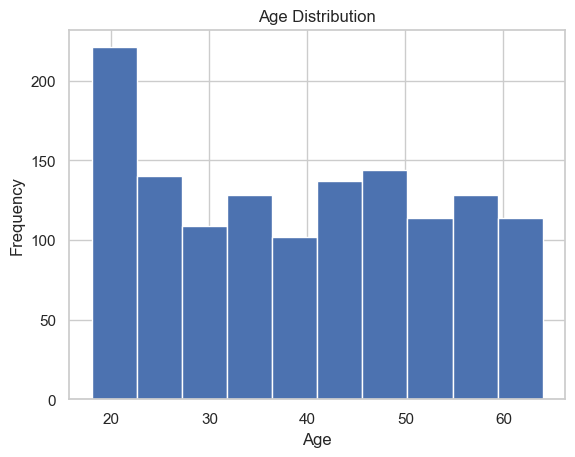

In [6]:
plt.hist(df['age'])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### Interpretation:
The histogram shows the distribution of age in the dataset. Most individuals fall between the ages of 20 and 50, indicating that the dataset mainly consists of young to middle-aged adults.

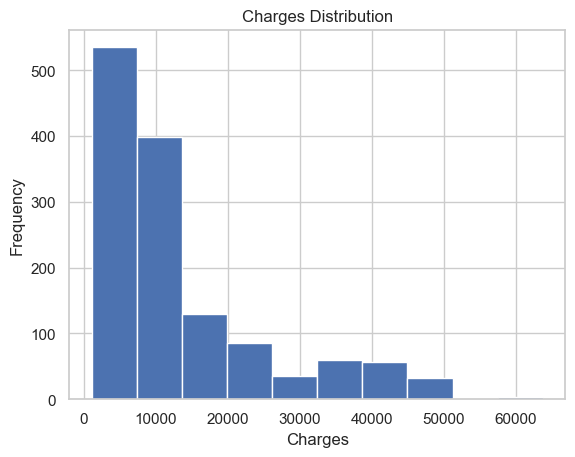

In [7]:
plt.hist(df['charges'])
plt.title("Charges Distribution")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

### Interpretation
This distribution of charges is right-skewed, meaning that most individuals have lower medical costs, while a few have very high charges. This indicates the presence of outliers.

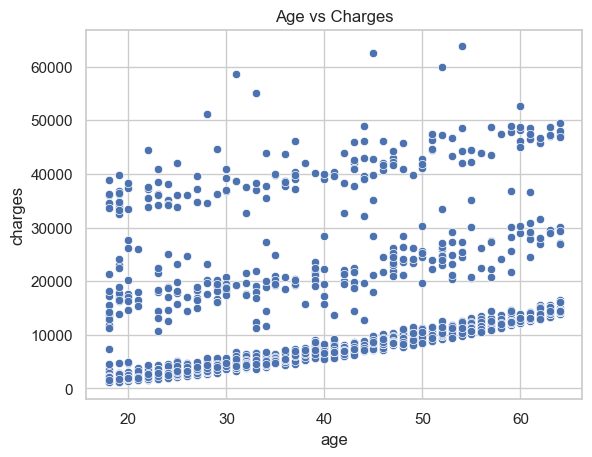

In [8]:
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Charges")
plt.show()

### Interpretation
The scatter plot shows a positive relationship between age and charges. As age increases, medical charges tend to increase, although there is some variability.

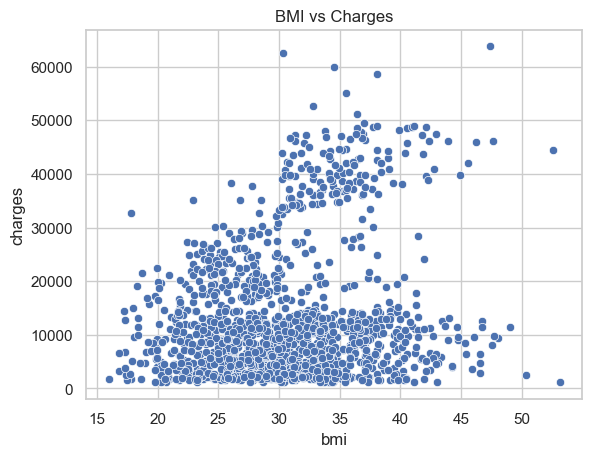

In [9]:
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Charges")
plt.show()

### Interpretation
There is a slight positive relationship between BMI and charges, indicating that individuals with higher BMI may incur higher medical costs.

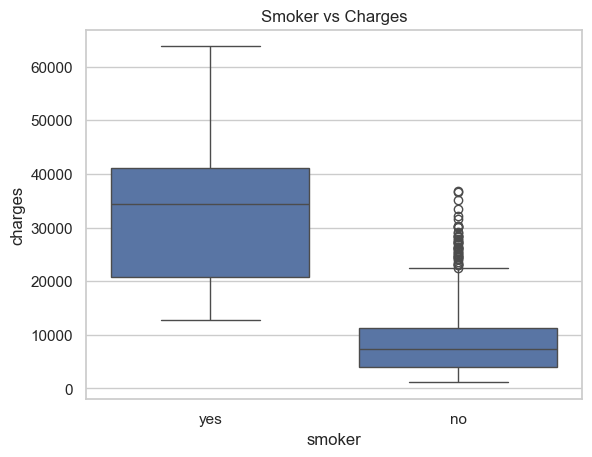

In [10]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoker vs Charges")
plt.show()

### Interpretation
The boxplot shows that smokers have significantly higher medical charges compared to non-smokers. This suggests that smoking is a major factor influencing insurance costs.

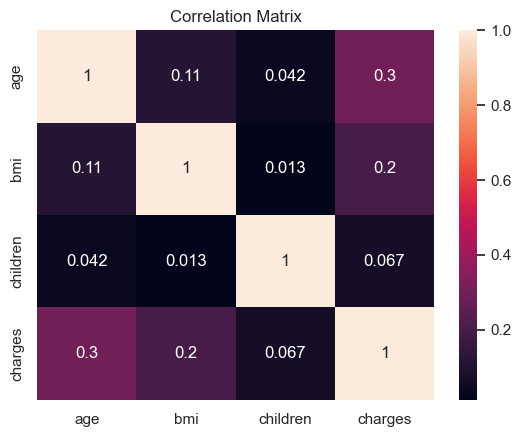

In [11]:
correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, annot=True)
plt.title("Correlation Matrix")
plt.show()

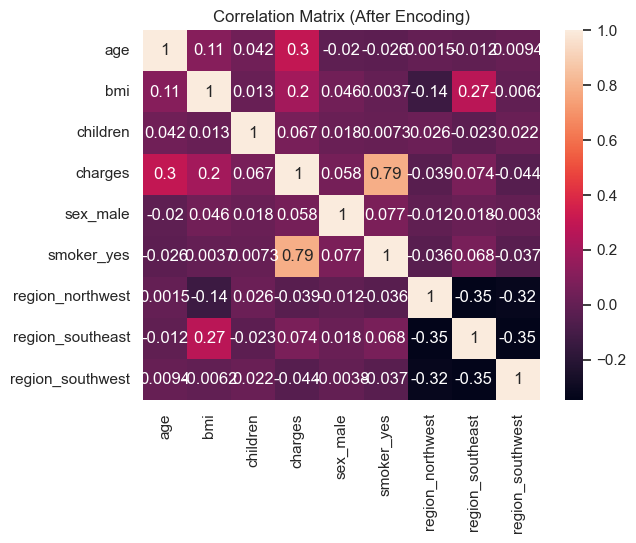

In [12]:
# Convert categorical variables into dummy variables
df_encoded = pd.get_dummies(df,drop_first=True)

corr = df_encoded.corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix (After Encoding)")
plt.show()

### Interpretation
The correlation matrix after encoding shows that smoking status (smoker_yes) has a strong positive correlation with charges (approximately 0.79). This indicates that smokers tend to have significantly higher medical costs compared to non-smokers.

In comparison, age shows a moderate correlation with charges, while BMI has a weaker relationship. Other variables such as number of children and region show very weak correlations.

Therefore, smoking is the most significant factor affecting insurance charges in this dataset.

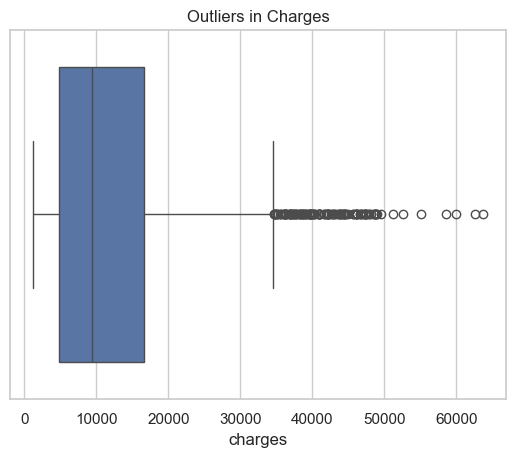

In [13]:
sns.boxplot(x=df['charges'])
plt.title("Outliers in Charges")
plt.show()

### Interpretation
The boxplot shows the presence of outliers in the charges variable. These are values that are significantly higher than the rest of the data.

These outliers are likely due to individuals with high medical expenses, possibly influenced by factors such as smoking, age, or health conditions.

Since these values represent real-world scenarios and are not data errors, they were retained for further analysis. However, they may be treated in later stages to improve model perfomance.

### Hypothesis
H0 (Null Hypothesis): Smoking has no effect on medical charges.
H1 (Alnternative Hypothesis): Smoking has a significant effect on medical charges.

In [15]:
# Hypothesis testing
df.groupby('smoker')['charges'].mean()

smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64

### Hypothesis Testing
The average charges for smokers are significantly higher than for non-smokers. This indicates a strong relationship between smoking status and medical costs.

Therefore, we reject the null hypothesis  and conclude that smoking has a significant impact on insurance charges.

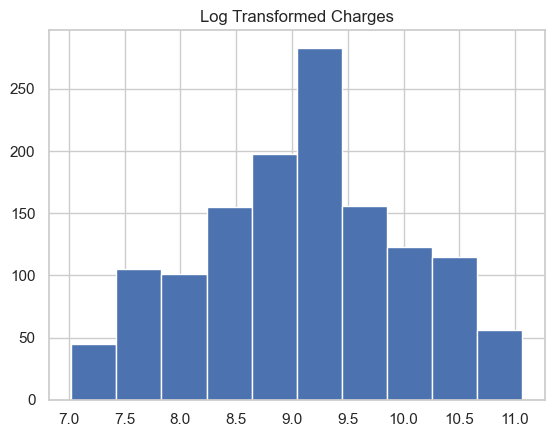

In [16]:
# Handling skewness
df['log_charges'] = np.log(df['charges'])

plt.hist(df['log_charges'])
plt.title("Log Transformed Charges")
plt.show()

### Handling Skewness
The distribution of charges was found to be right-skewed, with a few extremely high values. To address this, a log transformation was applied to normalize the data.

The transformed distribution appears more symmetric, which can improve the performance of machine learning models.

### Summary of Findings
- The dataset contains both numerical and categorical variables.
- No missing values were found.
- Charges are highly skewed with noticeable outliers.
- Smoking has the strongest impact on medical charges.
- Age and BMI show a positive  relationship with charges.
- Categorical variables were encoded for further analyses.